In [1]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geocat.viz as gv
import matplotlib.path as mpath

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
def calculate_grid_cell_area(lats, lons):
    """
    Calculates the area of each grid cell in a regular lat-lon grid.

    Args:
        lats (np.array): 1D array of latitude centers in degrees.
        lons (np.array): 1D array of longitude centers in degrees.

    Returns:
        np.array: 2D array (lats, lons) of grid cell areas in square meters.
    """
    # Earth radius
    R = 6371000  # meters

    # Convert degrees to radians
    lats_rad = np.deg2rad(lats)
    lons_rad = np.deg2rad(lons)

    # Calculate latitude bounds from centers (simple approximation for regular grids)
    lat_bounds = np.zeros(lats_rad.shape[0] + 1)
    lat_bounds[0] = lats_rad[0] - (lats_rad[1] - lats_rad[0]) / 2.
    lat_bounds[1:] = lats_rad[:] + (lats_rad[1] - lats_rad[0]) / 2.

    # Calculate longitude bounds (simple approximation for regular grids)
    lon_bounds = np.zeros(lons_rad.shape[0] + 1)
    lon_bounds[0] = lons_rad[0] - (lons_rad[1] - lons_rad[0]) / 2.
    lon_bounds[1:] = lons_rad[:] + (lons_rad[1] - lons_rad[0]) / 2.

    # Calculate the area factors using the difference in sine of latitude bounds
    lat_area_factor = np.sin(lat_bounds[1:]) - np.sin(lat_bounds[:-1])
    # Calculate the difference in longitude bounds
    lon_area_factor = lon_bounds[1:] - lon_bounds[:-1]

    # Area of each cell: Area = R^2 * delta_sin(lat) * delta_lon
    # Use meshgrid to create 2D arrays of the factors
    lon_factor_2d, lat_factor_2d = np.meshgrid(lon_area_factor, lat_area_factor)
    cell_areas = R**2 * lat_factor_2d * lon_factor_2d

    return cell_areas

In [3]:
# https://nsidc.org/sea-ice-today/sea-ice-tools#anchor-sea-ice-analysis-data-spreadsheets
# https://noaadata.apps.nsidc.org/NOAA/G02135/seaice_analysis/Sea_Ice_Index_Daily_Extent_G02135_v4.0.xlsx
filename = 'nsidc_sie.txt'
day = []
sie_nh = []
sie_sh = []

with open(filename, 'r') as f:
    for line in f:
        # Split the line into parts based on whitespace
        parts = line.strip().split()

        # Ensure there are at least two columns
        if len(parts) >= 2:
            # Append data to the respective lists
            day.append(int(parts[0]))
            sie_nh.append(float(parts[1]))
            sie_sh.append(float(parts[2]))

In [4]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

file = "OSISAF-GLO-SEAICE_CONC_CONT_TIMESERIES-SH-LA-OBS_multi-vars_180.00W-179.70E_90.00S-40.00S_2021-01-01-2021-12-31.nc"
ds_ice_sh = xr.open_dataset(os.path.join(data_path, file))
cell_area = calculate_grid_cell_area(ds_ice_sh.latitude, ds_ice_sh.longitude)
ds_ice_sh['cell_area'] = (("latitude", "longitude"), cell_area)
ice_mask = ds_ice_sh.ice_conc > 15
extent_ice_sh = (ice_mask * ds_ice_sh['cell_area']).sum(dim=["longitude", "latitude"])
extent_ice_sh = extent_ice_sh/1.0e12
extent_ice_sh = extent_ice_sh.where(extent_ice_sh != 0.0, np.nan)
extent_ice_sh = extent_ice_sh.interpolate_na(dim="time", method="linear")

file = "OSISAF-GLO-SEAICE_CONC_CONT_TIMESERIES-NH-LA-OBS_multi-vars_180.00W-179.70E_40.00N-90.00N_2021-01-01-2021-12-31.nc"
ds_ice_nh = xr.open_dataset(os.path.join(data_path, file))
cell_area = calculate_grid_cell_area(ds_ice_nh.latitude, ds_ice_nh.longitude)
ds_ice_nh['cell_area'] = (("latitude", "longitude"), cell_area)
ice_mask = ds_ice_nh.ice_conc > 15
extent_ice_nh = (ice_mask * ds_ice_nh['cell_area']).sum(dim=["longitude", "latitude"])
extent_ice_nh = extent_ice_nh/1.0e12
extent_ice_nh = extent_ice_nh.where(extent_ice_nh != 0.0, np.nan)
extent_ice_nh = extent_ice_nh.interpolate_na(dim="time", method="linear")

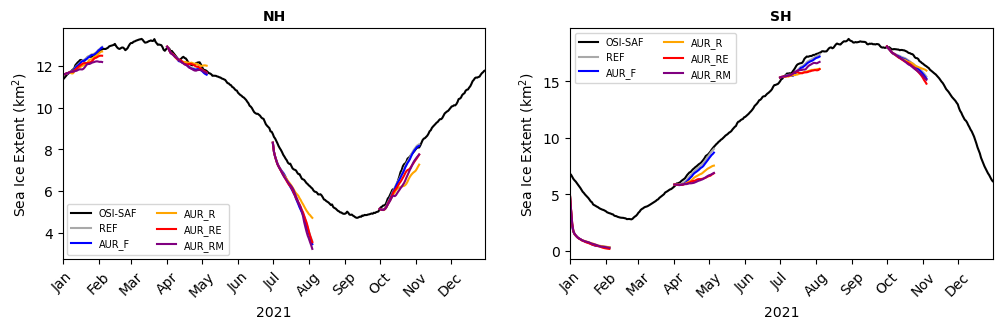

In [5]:
# Create composite time axis
t1 = pd.date_range(start='2021-01-01', end='2021-02-04', freq='1d')
t4 = pd.date_range(start='2021-04-01', end='2021-05-05', freq='1d')
t7 = pd.date_range(start='2021-07-01', end='2021-08-04', freq='1d')
t10 = pd.date_range(start='2021-10-01', end='2021-11-04', freq='1d')
x = pd.date_range(start='2021-01-01', end='2021-12-31', freq='1d')

# Months
months = {
    "JAN": [1,  t1],
    "APR": [4,  t4],
    "JUL": [7,  t7],
    "OCT": [10, t10]
}

# Create plot
fig, ax = plt.subplots(1, 2, figsize=(12,3))

# Add observation
ax[0].plot(x, extent_ice_nh, color="black", label="OSI-SAF")
ax[1].plot(x, extent_ice_sh, color="black", label="OSI-SAF")

irow = 0
for label, val in months.items():
    # Load datasets
    ds_datm = xr.open_dataset(os.path.join(data_path, f"2021{val[0]:02d}01_datm/ice_merged_35d_remap_bil.nc"))
    ds_datm = ds_datm.reindex(latitude=ds_datm.latitude[::-1])
    ds_aur0 = xr.open_dataset(os.path.join(data_path, f"2021{val[0]:02d}01_aurora/ice_merged_35d_remap_bil.nc"))
    ds_aur0 = ds_aur0.reindex(latitude=ds_aur0.latitude[::-1])
    ds_aur1 = xr.open_dataset(os.path.join(data_path, f"2021{val[0]:02d}01_aurora_r2/ice_merged_35d_remap_bil.nc"))
    ds_aur1 = ds_aur1.reindex(latitude=ds_aur1.latitude[::-1])
    ds_aur2 = xr.open_dataset(os.path.join(data_path, f"2021{val[0]:02d}01_aurora_r3/ice_merged_35d_remap_bil.nc"))
    ds_aur2 = ds_aur2.reindex(latitude=ds_aur2.latitude[::-1])
    ds_aur3 = xr.open_dataset(os.path.join(data_path, f"2021{val[0]:02d}01_aurora_two_way_r4/ice_merged_35d_remap_bil.nc"))
    ds_aur3 = ds_aur3.reindex(latitude=ds_aur3.latitude[::-1])

    # Cell area for NH
    ds_datm_nh = ds_datm.sel(latitude=slice(40, 90), longitude=slice(0, 360))
    cell_area_nh = calculate_grid_cell_area(ds_datm_nh.latitude, ds_datm_nh.longitude)

    # Subset for NH
    # DATM
    ds_datm_nh = ds_datm.sel(latitude=slice(40, 90), longitude=slice(0, 360))
    ice_mask = ds_datm_nh.aice_d*100 > 15
    extent_datm_nh = (ice_mask * cell_area_nh).sum(dim=["longitude", "latitude"])
    extent_datm_nh = extent_datm_nh/1.0e12
    ax[0].plot(val[1], extent_datm_nh, color="darkgray", label="REF")

    # AURORA Forced
    ds_aur0_nh = ds_aur0.sel(latitude=slice(40, 90), longitude=slice(0, 360))
    ice_mask = ds_aur0_nh.aice_d*100 > 15
    extent_aur0_nh = (ice_mask * cell_area_nh).sum(dim=["longitude", "latitude"])
    extent_aur0_nh = extent_aur0_nh/1.0e12
    ax[0].plot(val[1], extent_aur0_nh, color="blue", label="AUR_F")

    # AURORA Free
    ds_aur1_nh = ds_aur1.sel(latitude=slice(40, 90), longitude=slice(0, 360))
    ice_mask = ds_aur1_nh.aice_d*100 > 15
    extent_aur1_nh = (ice_mask * cell_area_nh).sum(dim=["longitude", "latitude"])
    extent_aur1_nh = extent_aur1_nh/1.0e12
    ax[0].plot(val[1], extent_aur1_nh, color="orange", label="AUR_R")

    # AURORA Free + ERA5 SST
    ds_aur2_nh = ds_aur2.sel(latitude=slice(40, 90), longitude=slice(0, 360))
    ice_mask = ds_aur2_nh.aice_d*100 > 15
    extent_aur2_nh = (ice_mask * cell_area_nh).sum(dim=["longitude", "latitude"])
    extent_aur2_nh = extent_aur2_nh/1.0e12
    ax[0].plot(val[1], extent_aur2_nh, color="red", label="AUR_RE")

    # AURORA Free + MOM6 SST
    ds_aur3_nh = ds_aur3.sel(latitude=slice(40, 90), longitude=slice(0, 360))
    ice_mask = ds_aur3_nh.aice_d*100 > 15
    extent_aur3_nh = (ice_mask * cell_area_nh).sum(dim=["longitude", "latitude"])
    extent_aur3_nh = extent_aur3_nh/1.0e12
    ax[0].plot(val[1], extent_aur3_nh, color="purple", label="AUR_RM")

    # Cell area for NH
    ds_datm_sh = ds_datm.sel(latitude=slice(-90, -40), longitude=slice(0, 360))
    cell_area_sh = calculate_grid_cell_area(ds_datm_sh.latitude, ds_datm_sh.longitude)

    # Subset for SH
    # DATM
    ds_datm_sh = ds_datm.sel(latitude=slice(-90, -40), longitude=slice(0, 360))
    ice_mask = ds_datm_sh.aice_d*100 > 15
    extent_datm_sh = (ice_mask * cell_area_sh).sum(dim=["longitude", "latitude"])
    extent_datm_sh = extent_datm_sh/1.0e12
    ax[1].plot(val[1], extent_datm_sh, color="darkgray", label="REF")

    # AURORA Forced
    ds_aur0_sh = ds_aur0.sel(latitude=slice(-90, -40), longitude=slice(0, 360))
    ice_mask = ds_aur0_sh.aice_d*100 > 15
    extent_aur0_sh = (ice_mask * cell_area_sh).sum(dim=["longitude", "latitude"])
    extent_aur0_sh = extent_aur0_sh/1.0e12
    ax[1].plot(val[1], extent_aur0_sh, color="blue", label="AUR_F")

    # AURORA Free
    ds_aur1_sh = ds_aur1.sel(latitude=slice(-90, -40), longitude=slice(0, 360))
    ice_mask = ds_aur1_sh.aice_d*100 > 15
    extent_aur1_sh = (ice_mask * cell_area_sh).sum(dim=["longitude", "latitude"])
    extent_aur1_sh = extent_aur1_sh/1.0e12
    ax[1].plot(val[1], extent_aur1_sh, color="orange", label="AUR_R")

    # AURORA Free + ERA5 SST
    ds_aur2_sh = ds_aur2.sel(latitude=slice(-90, -40), longitude=slice(0, 360))
    ice_mask = ds_aur2_sh.aice_d*100 > 15
    extent_aur2_sh = (ice_mask * cell_area_sh).sum(dim=["longitude", "latitude"])
    extent_aur2_sh = extent_aur2_sh/1.0e12
    ax[1].plot(val[1], extent_aur2_sh, color="red", label="AUR_RE")

    # AURORA Free + MOM6 SST
    ds_aur3_sh = ds_aur3.sel(latitude=slice(-90, -40), longitude=slice(0, 360))
    ice_mask = ds_aur3_sh.aice_d*100 > 15
    extent_aur3_sh = (ice_mask * cell_area_sh).sum(dim=["longitude", "latitude"])
    extent_aur3_sh = extent_aur3_sh/1.0e12
    ax[1].plot(val[1], extent_aur3_sh, color="purple", label="AUR_RM")

    # Set axises
    ax[0].set_xticks([])
    ax[0].set_xlabel('')
    ax[1].set_xticks([])
    ax[1].set_xlabel('')

    # Add legend
    if val[0] == 1:
        ax[0].legend(ncol=2, fontsize=7, loc='lower left')
        ax[1].legend(ncol=2, fontsize=7, loc='upper left')

# Add axises
ax[0].set_ylabel(r'Sea Ice Extent (km$^2$)')
ax[1].set_ylabel(r'Sea Ice Extent (km$^2$)')

# Add title
ax[0].set_title(f"NH", fontweight='bold', fontsize=10)
ax[1].set_title(f"SH", fontweight='bold', fontsize=10)

# Add x tick labels
first_days = [d for d in x if d.day == 1]
months = [d.strftime("%b") for d in x if d.day == 1]
ax[0].set_xlim(x[0], x[-1])
ax[0].set_xticks(first_days, labels=months)
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_xlabel('2021')
ax[1].set_xlim(x[0], x[-1])
ax[1].set_xticks(first_days, labels=months)
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_xlabel('2021')

# Save to file
filename = "s2s_sie.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)